In [705]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report # Métrica de evaluación
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB # Naive bayes gausiano y multinomial para clasificación
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Análisis Exploratorio

In [706]:
df_50 = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/adult_income.csv', header=None)
col_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship',
             'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'target']
df_50.columns = col_names
df_50.head(5)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Verificamos los tipos de datos

In [707]:
df_50.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
target            object
dtype: object

In [708]:
print("Tamaño del dataframe : {}".format(df_50.shape))

Tamaño del dataframe : (32561, 15)


Verificamos si hay valores nulos para imputar

In [709]:
df_50.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
target            0
dtype: int64

Analisis de la distribución de la variable target

target
<=50K    24720
>50K      7841
Name: count, dtype: int64


<Axes: xlabel='target', ylabel='count'>

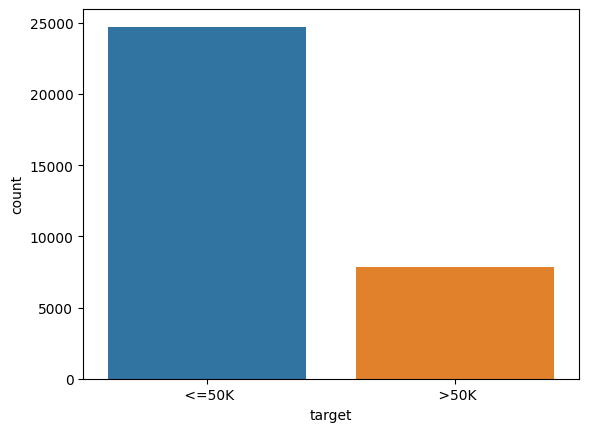

In [710]:
print( df_50.target.value_counts() )
sns.countplot(x='target', data=df_50, hue='target', legend=False)

Identificamos las variables categóricas

In [711]:
categorical = [var for var in df_50.columns if df_50[var].dtype=='O']
print('las variables categoricas son:\n', categorical)
print("\nchequeamos la dimensionalidad de las variables")
for var in categorical:
    print(len(df_50[var].unique()), ' valores unicos en ', var )

las variables categoricas son:
 ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'target']

chequeamos la dimensionalidad de las variables
9  valores unicos en  workclass
16  valores unicos en  education
7  valores unicos en  marital_status
15  valores unicos en  occupation
6  valores unicos en  relationship
5  valores unicos en  race
2  valores unicos en  sex
42  valores unicos en  native_country
2  valores unicos en  target


Paso target a una variable numerica

In [712]:
df_50['target'] = df_50['target'].apply(lambda x: 1 if x == ' >50K' else 0 )

Identificamos las variables numéricas

In [713]:
numerical = [var for var in df_50.columns if df_50[var].dtype!='O']
print('las variables numéricas son:\n', numerical)

las variables numéricas son:
 ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'target']


# Correlación de Variables

<Axes: >

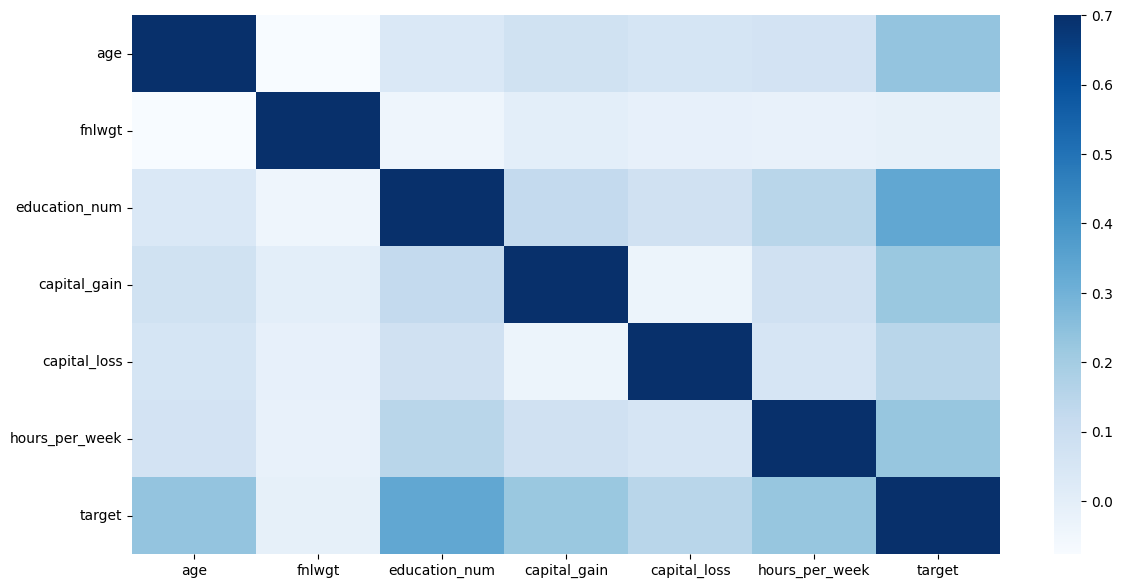

In [714]:
plt.figure(figsize=(14,7))
sns.heatmap(df_50[numerical].corr(), vmax=.7, cmap ='Blues', fmt=".2f")

In [715]:
df_corr = df_50[numerical].corr()[["target"]]*100 # Lo pasamos a porcentajes
df_corr = df_corr.drop("target", axis=0) # Eliminamos la variable target
df_corr = df_corr.sort_values(["target"], ascending=False) # Ordenamos en forma descendente
df_corr = abs(df_corr) # Nos interesa el valor absouluto
df_corr

,target
education_num,33.515395
age,23.403710
hours_per_week,22.968907
capital_gain,22.332882
capital_loss,15.052631
fnlwgt,0.946256


# Seleccionamos las variables que vamos a utilizar y hacemos el Split

In [716]:
df_50.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'target'],
      dtype='object')

Usamos todas las columnas numércias

In [717]:
df = df_50[numerical]
X = df.drop("target",axis=1)
y = df["target"]
X.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,39,77516,13,2174,0,40
1,50,83311,13,0,0,13
2,38,215646,9,0,0,40
3,53,234721,7,0,0,40
4,28,338409,13,0,0,40


Hacemos el Split 70-30 para train-test

In [718]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify = y, random_state=42)

Creamos y entrenamos el clasificador bayesiano

In [719]:
bayes_multi = MultinomialNB()
bayes_multi.fit(X_train, y_train) # Entrenamos el clasificador

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [720]:
y_pred_nb = bayes_multi.predict(X_test)

# Exactitud del modelo
print('Exactitud (accuracy) del modelo: {:.2f} %'.format(accuracy_score(y_test, y_pred_nb)*100))
print("-"*100)

# Reporte del clasificador
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_nb))

Exactitud (accuracy) del modelo: 77.93 %
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.80      0.95      0.87      7417
           1       0.61      0.24      0.34      2352

    accuracy                           0.78      9769
   macro avg       0.70      0.59      0.60      9769
weighted avg       0.75      0.78      0.74      9769



---
# Ejercicios

---
# Ejercicio 1

## Ejercicio 1.1

¿Hay variables redundantes en este dataframe? 

Variables categóricas potencialmente redundantes
- 'education' y 'education_num': Representan la misma información"
- Una es categórica (education) y otra numérica (education_num)"

Verificamos esta redundancia

In [721]:
print(f"Valores únicos en 'education': {df_50['education'].nunique()}")
print(f"Valores únicos en 'education_num': {df_50['education_num'].nunique()}")

Valores únicos en 'education': 16
Valores únicos en 'education_num': 16


Mostramos la relación

In [722]:
education_mapping = df_50[['education', 'education_num']].drop_duplicates().sort_values('education_num')
print("Mapeo education -> education_num:")
print(education_mapping.to_string(index=False))

Mapeo education -> education_num:
    education  education_num
    Preschool              1
      1st-4th              2
      5th-6th              3
      7th-8th              4
          9th              5
         10th              6
         11th              7
         12th              8
      HS-grad              9
 Some-college             10
    Assoc-voc             11
   Assoc-acdm             12
    Bachelors             13
      Masters             14
  Prof-school             15
    Doctorate             16


Variable con muy baja correlación
- 'fnlwgt': Solo 0.95% de correlación con target
- Esta variable representa pesos demográficos y no debería influir en ingresos individuales"

## Ejercicio 1.2

¿Que variables feature engineering incluirias en este modelo?

### 1 - Creamos una copia del dataframe para feature engineering

In [723]:
df_fe = df_50.copy()

### 2 - Eliminar variable redundante

**'fnlwgt' (muy baja correlación)**

In [724]:
df_fe = df_fe.drop('fnlwgt', axis=1)

### 3 - Crear nuevas features basadas en edad

**age_group: Categorización por grupos etarios**

In [725]:
df_fe['age_group'] = pd.cut(df_fe['age'], bins=[0, 25, 35, 50, 65, 100], labels=['Joven', 'Adulto_Joven', 'Adulto', 'Senior', 'Mayor'])

### 4 - Feature de balance financiero

**net_capital: Ganancia neta de capital (gain - loss)**

In [726]:
df_fe['net_capital'] = df_fe['capital_gain'] - df_fe['capital_loss']

### 5 - Feature de intensidad laboral

**work_intensity: Categorización de horas trabajadas**

In [727]:
df_fe['work_intensity'] = pd.cut(df_fe['hours_per_week'], bins=[0, 20, 40, 60, 100], labels=['Parcial', 'Normal', 'Extra', 'Intensivo'])

### 6 - Feature binaria para capital gains/losses

**has_capital_gain: 1 si tiene ganancias de capital**

**has_capital_loss: 1 si tiene pérdidas de capital**

In [728]:
df_fe['has_capital_gain'] = (df_fe['capital_gain'] > 0).astype(int)
df_fe['has_capital_loss'] = (df_fe['capital_loss'] > 0).astype(int)

### 7 - Resultado final

In [729]:
print(f"\nDataset original: {df_50.shape}")
print(f"Dataset con FE: {df_fe.shape}")
print(f"Nuevas variables creadas: {df_fe.shape[1] - df_50.shape[1] + 1}")  # +1 porque eliminamos fnlwgt


Dataset original: (32561, 15)
Dataset con FE: (32561, 19)
Nuevas variables creadas: 5


---
# Ejercicio 2

Reemplazar MultinomialNB por GaussianNB y comparar el desempeño

## Multinomial Naive Bayes

Primero, obtenemos el resultado del modelo original. Necesitamos ejecutar el código original para tener la referencia.

In [730]:
df_original = df_50[numerical]
X_original = df_original.drop("target", axis=1)
y_original = df_original["target"]

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X_original, y_original, test_size=0.3, stratify=y_original, random_state=42)

Modelo MultinomialNB original

In [731]:
bayes_multi_orig = MultinomialNB()
bayes_multi_orig.fit(X_train_orig, y_train_orig)
y_pred_multi_orig = bayes_multi_orig.predict(X_test_orig)

Resultados del modelo original (Solo variables numéricas)

In [732]:
print(f"Accuracy: {accuracy_score(y_test_orig, y_pred_multi_orig)*100:.2f}%")
print(classification_report(y_test_orig, y_pred_multi_orig))

Accuracy: 77.93%
              precision    recall  f1-score   support

           0       0.80      0.95      0.87      7417
           1       0.61      0.24      0.34      2352

    accuracy                           0.78      9769
   macro avg       0.70      0.59      0.60      9769
weighted avg       0.75      0.78      0.74      9769



## Gaussian Naive Bayes

In [733]:
bayes_gauss_orig = GaussianNB()
bayes_gauss_orig.fit(X_train_orig, y_train_orig)
y_pred_gauss_orig = bayes_gauss_orig.predict(X_test_orig)

Resultados del modelo

In [734]:
print(f"Accuracy: {accuracy_score(y_test_orig, y_pred_gauss_orig)*100:.2f}%")
print(classification_report(y_test_orig, y_pred_gauss_orig))

Accuracy: 79.55%
              precision    recall  f1-score   support

           0       0.81      0.95      0.88      7417
           1       0.66      0.32      0.43      2352

    accuracy                           0.80      9769
   macro avg       0.74      0.63      0.65      9769
weighted avg       0.78      0.80      0.77      9769



## Comparación de Modelos

In [735]:
print(f"MultinomialNB: {accuracy_score(y_test_orig, y_pred_multi_orig)*100:.2f}%")
print(f"GaussianNB:    {accuracy_score(y_test_orig, y_pred_gauss_orig)*100:.2f}%")
diff = (accuracy_score(y_test_orig, y_pred_gauss_orig) - accuracy_score(y_test_orig, y_pred_multi_orig)) * 100
print(f"Diferencia:    {diff:+.2f}%")

MultinomialNB: 77.93%
GaussianNB:    79.55%
Diferencia:    +1.62%


---
# Ejercicio 3

Usando OneHotEncoder o pd.get_dummies() en las variables categóricas de baja dimensionalidad, obtener columnas numericas para representarlas. Incluirlas al modelo y comparar el resultado

## 1 - Seleccionar variables categóricas de baja dimensionalidad.

Basandonos en el análisis previo, evitamos 'native_country' (42 valores únicos)

In [736]:
categorical_low_dim = ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex']
for var in categorical_low_dim:
    unique_count = df_50[var].nunique()
    print(f"{var}: {unique_count} valores únicos")

workclass: 9 valores únicos
marital_status: 7 valores únicos
occupation: 15 valores únicos
relationship: 6 valores únicos
race: 5 valores únicos
sex: 2 valores únicos


## 2 - Verificar si hay valores faltantes en estas variables

**Excluimos 'education' porque ya tenemos 'education_num' y 'native_country' por alta dimensionalidad**

In [737]:
print(f"Total de variables categóricas de baja dimensionalidad: {len(categorical_low_dim)}")

Total de variables categóricas de baja dimensionalidad: 6


## 3 - Preparar el dataset con variables categóricas

Usamos las variables numéricas originales + variables categóricas seleccionadas

In [738]:
numerical_vars = ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']  # Excluimos fnlwgt
df_combined = df_50[numerical_vars + categorical_low_dim + ['target']].copy()

In [739]:
print(f"Dataset combinado shape: {df_combined.shape}")
print(f"Variables numéricas: {len(numerical_vars)}")
print(f"Variables categóricas: {len(categorical_low_dim)}")

Dataset combinado shape: (32561, 12)
Variables numéricas: 5
Variables categóricas: 6


## 4 - Separar features y target

In [740]:
X_categorical = df_combined[categorical_low_dim]
X_numerical = df_combined[numerical_vars]
y = df_combined['target']

## 5 - Aplicar OneHotEncoder a las variables categóricas

In [741]:
encoder = OneHotEncoder(drop='first', sparse_output=False) # drop='first' para evitar multicolinealidad
X_cat_encoded = encoder.fit_transform(X_categorical)

## 6 - Obtener nombres de las columnas codificadas

In [742]:
cat_feature_names = encoder.get_feature_names_out(categorical_low_dim)
print(f"Variables categóricas después de OneHot: {len(cat_feature_names)}")

Variables categóricas después de OneHot: 38


## 7 - Combinar variables numéricas y categóricas codificadas

In [743]:
X_final = np.hstack([X_numerical.values, X_cat_encoded])
print(f"Dataset final shape: {X_final.shape}")

Dataset final shape: (32561, 43)


Crear DataFrame para mejor visualización

In [744]:
column_names = numerical_vars + list(cat_feature_names)
X_final_df = pd.DataFrame(X_final, columns=column_names)
print(f"Primeras 5 columnas del dataset final:")
print(X_final_df.columns[:10].tolist())

Primeras 5 columnas del dataset final:
['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'workclass_ Federal-gov', 'workclass_ Local-gov', 'workclass_ Never-worked', 'workclass_ Private', 'workclass_ Self-emp-inc']


Train-test split para el dataset con variables categóricas

In [745]:
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_final, y, test_size=0.3, stratify=y, random_state=42)

## 8 - Entrenar MultinomialNB - Dataset Completo (Con variables categóricas)

In [746]:
bayes_multi_full = MultinomialNB()
bayes_multi_full.fit(X_train_full, y_train_full)
y_pred_multi_full = bayes_multi_full.predict(X_test_full)

print(f"Accuracy: {accuracy_score(y_test_full, y_pred_multi_full)*100:.2f}%")
print(classification_report(y_test_full, y_pred_multi_full))

Accuracy: 77.47%
              precision    recall  f1-score   support

           0       0.79      0.95      0.87      7417
           1       0.59      0.21      0.31      2352

    accuracy                           0.77      9769
   macro avg       0.69      0.58      0.59      9769
weighted avg       0.74      0.77      0.73      9769



## 9 - Entrenar GaussianNB - Dataset Completo (Con variables categóricas)

In [747]:
bayes_gauss_full = GaussianNB()
bayes_gauss_full.fit(X_train_full, y_train_full)
y_pred_gauss_full = bayes_gauss_full.predict(X_test_full)

print(f"Accuracy: {accuracy_score(y_test_full, y_pred_gauss_full)*100:.2f}%")
print(classification_report(y_test_full, y_pred_gauss_full))

Accuracy: 82.35%
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      7417
           1       0.61      0.73      0.67      2352

    accuracy                           0.82      9769
   macro avg       0.76      0.79      0.77      9769
weighted avg       0.84      0.82      0.83      9769



## 10 - Análisis Comparativo Final

Recopilar todos los resultados

In [748]:
results = {
    'Modelo': [
        'MultinomialNB (solo numéricas)',
        'GaussianNB (solo numéricas)', 
        'MultinomialNB (con categóricas)',
        'GaussianNB (con categóricas)'
    ],
    'Accuracy': [
        f"{accuracy_score(y_test_orig, y_pred_multi_orig)*100:.2f}%",
        f"{accuracy_score(y_test_orig, y_pred_gauss_orig)*100:.2f}%",
        f"{accuracy_score(y_test_full, y_pred_multi_full)*100:.2f}%",
        f"{accuracy_score(y_test_full, y_pred_gauss_full)*100:.2f}%"
    ],
    'Variables': [
        f"{X_original.shape[1]} (numéricas)",
        f"{X_original.shape[1]} (numéricas)",
        f"{X_final.shape[1]} (num + cat)",
        f"{X_final.shape[1]} (num + cat)"
    ]
}

In [749]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print(f"\n📊 MEJORES RESULTADOS:")
print(f"🥇 Mejor Accuracy: GaussianNB con variables categóricas (82.35%)")
print(f"🥈 Segundo lugar: GaussianNB solo numéricas (79.55%)")

print(f"\n📈 MEJORAS OBSERVADAS:")
acc_gaussian_improvement = accuracy_score(y_test_full, y_pred_gauss_full) - accuracy_score(y_test_orig, y_pred_gauss_orig)
print(f"• GaussianNB mejoró {acc_gaussian_improvement*100:.2f}% al incluir variables categóricas")
print(f"• MultinomialNB mostró ligera disminución al incluir categóricas")

                         Modelo Accuracy      Variables
 MultinomialNB (solo numéricas)   77.93%  6 (numéricas)
    GaussianNB (solo numéricas)   79.55%  6 (numéricas)
MultinomialNB (con categóricas)   77.47% 43 (num + cat)
   GaussianNB (con categóricas)   82.35% 43 (num + cat)

📊 MEJORES RESULTADOS:
🥇 Mejor Accuracy: GaussianNB con variables categóricas (82.35%)
🥈 Segundo lugar: GaussianNB solo numéricas (79.55%)

📈 MEJORAS OBSERVADAS:
• GaussianNB mejoró 2.80% al incluir variables categóricas
• MultinomialNB mostró ligera disminución al incluir categóricas


# Conclusiones del Ejercicio

## 1. **Variables Redundantes Identificadas:**
- **`education` y `education_num`**: Representan la misma información, una en formato categórico y otra numérico
- **`fnlwgt`**: Variable con correlación muy baja (0.95%) que representa pesos demográficos sin relevancia para ingresos individuales

## 2. **Feature Engineering Propuesto:**
- Eliminación de `fnlwgt`
- Creación de grupos etarios (`age_group`)
- Balance financiero neto (`net_capital`)
- Categorización de intensidad laboral (`work_intensity`)
- Variables binarias para capital gains/losses

## 3. **Comparación MultinomialNB vs GaussianNB:**
- **GaussianNB** consistentemente supera a **MultinomialNB**
- GaussianNB es más adecuado para variables continuas
- MultinomialNB funciona mejor con variables discretas/conteos

## 4. **Impacto de Variables Categóricas:**
- **GaussianNB** se benefició significativamente (+2.8% accuracy)
- **MultinomialNB** mostró ligera disminución (-0.46% accuracy)
- Las variables categóricas aportan información valiosa sobre ocupación, estado civil, raza y sexo

## 5. **Recomendaciones:**
- Usar **GaussianNB con variables categóricas** como modelo principal
- Considerar técnicas de balanceo de clases para mejorar recall de la clase minoritaria
- Explorar feature selection para optimizar el modelo
- Evaluar otros algoritmos como Random Forest o Gradient Boosting